#QUESTION:WHAT ARE THE FUTURE SALES?

In [1]:
#import librarues
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

/home/vaidehi-deogade/Desktop/Konverge/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
#load dataset
df = pd.read_csv("/home/vaidehi-deogade/Desktop/Konverge/Projects/olist_ml_analytics/raw_data/processed_data/cleaned_dataset.csv")
df.head()

,Unnamed: 0,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,...,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english
0,0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,...,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
1,1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,...,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
2,2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,...,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
3,3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,...,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,perfumery
4,4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,...,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,auto


In [3]:
# Ensure datetime
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

#convert data column to datetimes
df['order_purchase_timestamp']=pd.to_datetime(df['order_purchase_timestamp'])

#set as index
df.set_index('order_purchase_timestamp',inplace=True)

#total order per month 
monthly_orders = df.resample('M').size()
#convert into dataframe
ts=monthly_orders.to_frame(name='order')
print(ts.head())

                          order
order_purchase_timestamp       
2016-09-30                    3
2016-10-31                  379
2016-11-30                    0
2016-12-31                    1
2017-01-31                 1008


/tmp/ipykernel_12529/551937061.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_orders = df.resample('M').size()


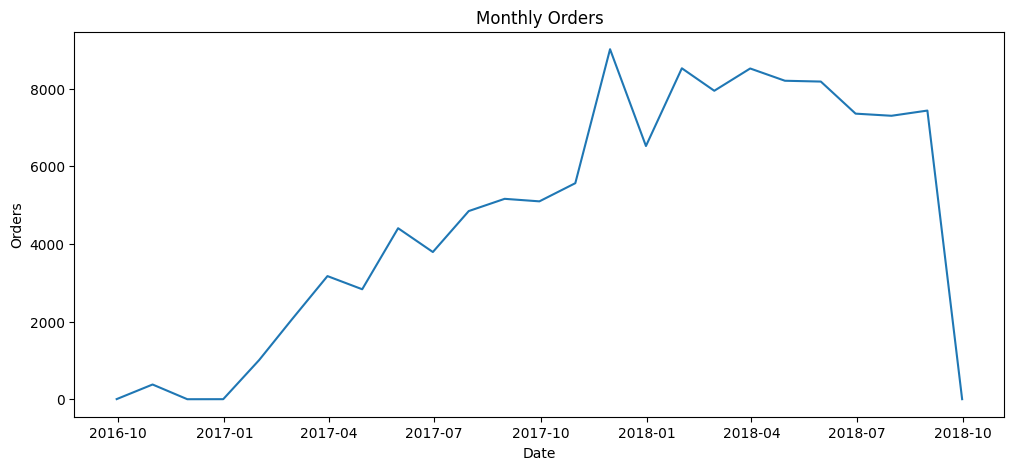

In [4]:
#visual time series
plt.figure(figsize=(12,5))
plt.plot(ts.index, ts['order'])
plt.title("Monthly Orders")
plt.xlabel("Date")
plt.ylabel("Orders")
plt.show()

In [5]:
#stationarity(adf test)
def check_stationarity(series):
    result=adfuller(series)
    print("ADF Statistic:",result[0])
    print("p-value:",result[1])
    if result[1]<0.05:
        print("Data is stationary")
    else:
        print("Data is not stationary")
check_stationarity(ts['order'])

ADF Statistic: -0.7355115406056555
p-value: 0.8373356143340661
Data is not stationary


In [6]:
# #apply differencing
# ts['diff_orders']=ts['order'].diff()
# #drop na values
# ts_diff=ts.dropna()
# #check stationarity
# check_stationarity(ts_diff['diff_orders'])

In [7]:
# #seasonal differencing
# ts['seasonal_diff']=ts['order']-ts['order'].shift(12)
# #drop na values
# ts_seasonal=ts.dropna()
# #check stationarity
# check_stationarity(ts_seasonal['seasonal_diff'])

In [8]:
#combined difference
ts['diff_combined']=ts['order'].diff().diff().diff(12)
#drop na values
ts_combined=ts.dropna()
#check stationarity
check_stationarity(ts_combined['diff_combined'])

ADF Statistic: -6.931947469792326
p-value: 1.0784669524643867e-09
Data is stationary


In [9]:
#train-test split
train=ts[:-12]
test=ts[-12:]
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (13, 2)
Test shape: (12, 2)


In [10]:
print(ts['order'].mean())

4691.76


In [11]:
#ARIMA
# from statsmodels.tsa.arima.model import ARIMA
#d=2 for 2nd diff
model_arima = ARIMA(train['order'], order=(1,2,1))
model_arima_fit = model_arima.fit()

#for 12 months
forecast_arima = model_arima_fit.forecast(steps=12)

#evaluate
mae_arima=mean_absolute_error(test['order'],forecast_arima)
print("ARIMA MAE:",mae_arima)
rmse_arima=np.sqrt(mean_squared_error(test['order'],forecast_arima))
print("ARIMA RSME: ",rmse_arima)

ARIMA MAE: 1923.6865451463375
ARIMA RSME:  3314.627462506682


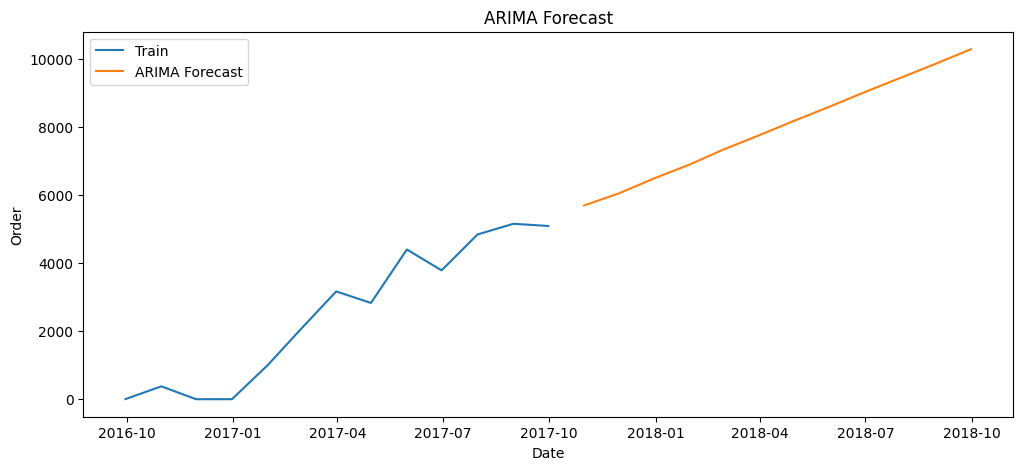

In [12]:
#arima plot
plt.figure(figsize=(12,5))
plt.plot(train.index, train['order'], label='Train')
# plt.plot(test.index, test['order'], label='Test')
plt.plot(test.index, forecast_arima, label='ARIMA Forecast')
plt.title("ARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Order")
plt.legend()
plt.show()

In [13]:
print(forecast_arima.index)
print(test.index)

DatetimeIndex(['2017-10-31', '2017-11-30', '2017-12-31', '2018-01-31',
               '2018-02-28', '2018-03-31', '2018-04-30', '2018-05-31',
               '2018-06-30', '2018-07-31', '2018-08-31', '2018-09-30'],
              dtype='datetime64[ns]', freq='ME')
DatetimeIndex(['2017-10-31', '2017-11-30', '2017-12-31', '2018-01-31',
               '2018-02-28', '2018-03-31', '2018-04-30', '2018-05-31',
               '2018-06-30', '2018-07-31', '2018-08-31', '2018-09-30'],
              dtype='datetime64[ns]', name='order_purchase_timestamp', freq='ME')


In [14]:
#SARIMA
#d=2 for 2nd diff
model_sarima = SARIMAX(train['order'], order=(1,2,1),seasonal_order=(1,0,1,12))
result_sarima= model_sarima.fit()

#for 12 months
forecast_sarima = result_sarima.forecast(steps=12)

#evaluate
mae_sarima=mean_absolute_error(test['order'],forecast_sarima)
print("SARIMA MAE:",mae_sarima)
rmse_sarima=np.sqrt(mean_squared_error(test['order'],forecast_sarima))
print("SARIMA RSME: ",rmse_sarima)

/home/vaidehi-deogade/Desktop/Konverge/.venv/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


SARIMA MAE: 2306.992320347895
SARIMA RSME:  3501.594652293191


/home/vaidehi-deogade/Desktop/Konverge/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


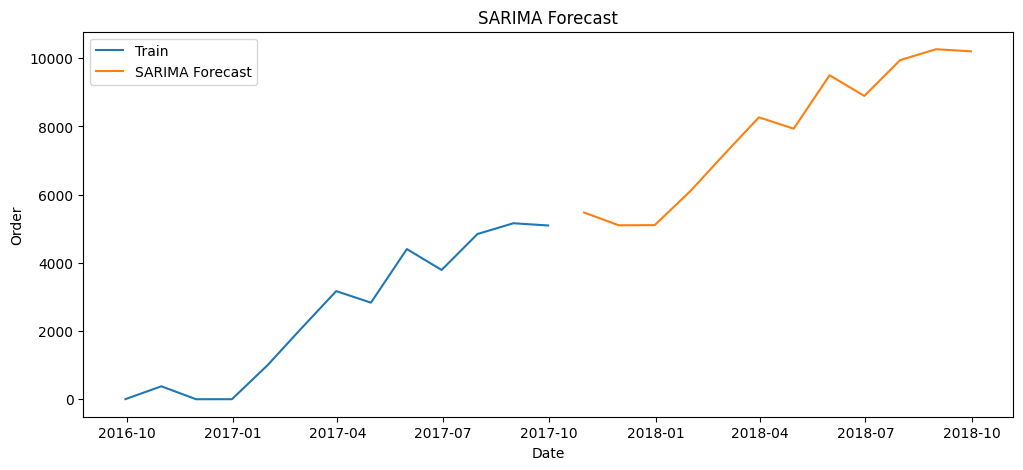

In [15]:
#plot
plt.figure(figsize=(12,5))
plt.plot(train.index, train['order'], label='Train')
# plt.plot(test.index, test['order'], label='Test')
plt.plot(test.index, forecast_sarima, label='SARIMA Forecast')
plt.title("SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Order")
plt.legend()
plt.show()

In [16]:
print(forecast_sarima.index)
print(test.index)

DatetimeIndex(['2017-10-31', '2017-11-30', '2017-12-31', '2018-01-31',
               '2018-02-28', '2018-03-31', '2018-04-30', '2018-05-31',
               '2018-06-30', '2018-07-31', '2018-08-31', '2018-09-30'],
              dtype='datetime64[ns]', freq='ME')
DatetimeIndex(['2017-10-31', '2017-11-30', '2017-12-31', '2018-01-31',
               '2018-02-28', '2018-03-31', '2018-04-30', '2018-05-31',
               '2018-06-30', '2018-07-31', '2018-08-31', '2018-09-30'],
              dtype='datetime64[ns]', name='order_purchase_timestamp', freq='ME')


11:17:36 - cmdstanpy - INFO - Chain [1] start processing
11:17:36 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE:  3809.4618949984156
Prophet RMSE:  4923.758798642152


/home/vaidehi-deogade/Desktop/Konverge/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


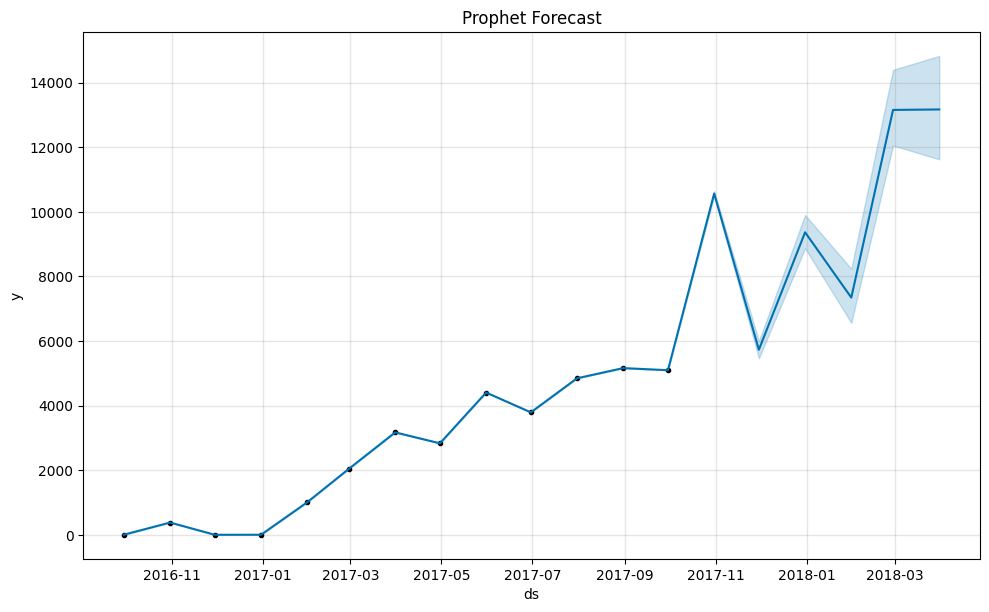

In [17]:
#PROPHET
#prepare the data
prophet_df=ts.reset_index()[['order_purchase_timestamp','order']]
prophet_df.columns=['ds' , 'y']

#rain test split
train_p=prophet_df[:-12]
test_p=prophet_df[-12:]

#train model
model=Prophet(yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False)
model.fit(train_p)

#future dataframe
future=model.make_future_dataframe(periods=6,freq='M')
forecast=model.predict(future)

#predic the test period
forecast_prophet = forecast['yhat'][-12:].values

#evaluation
mae_prophet=mean_absolute_error(test_p['y'],forecast_prophet)
print("Prophet MAE: ",mae_prophet)
rmse_prophet = np.sqrt(mean_squared_error(test_p['y'],forecast_prophet))
print("Prophet RMSE: ",rmse_prophet)

#plot
fig=model.plot(forecast)
plt.title("Prophet Forecast")
plt.show()

In [18]:
print(type(forecast))

<class 'pandas.core.frame.DataFrame'>


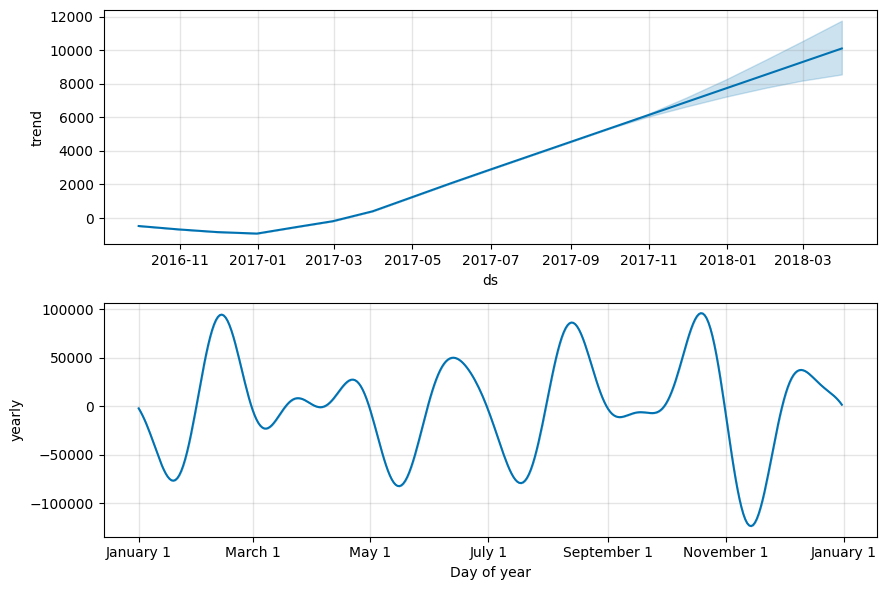

In [19]:
model.plot_components(forecast)
plt.show()

In [20]:
#Model comparison
comparison = pd.DataFrame({
    "Model": ['ARIMA','SARIMA','Prophet'],
    "MAE":[mae_arima,mae_sarima,mae_prophet],
    "RMSE":[rmse_arima,rmse_sarima,rmse_prophet]
})
print(comparison)

     Model          MAE         RMSE
0    ARIMA  1923.686545  3314.627463
1   SARIMA  2306.992320  3501.594652
2  Prophet  3809.461895  4923.758799
